In [1]:
import os
import sys
import argparse
from dotenv import load_dotenv

if __name__ == "__main__":
    curr_directory = os.getcwd()
    print("\nStarting Directory:", curr_directory)
    if not curr_directory.endswith("app"):
        if curr_directory.endswith("TFG_Miquel"):
            os.chdir("./app") 
        else: os.chdir("../") 
        print("New Directory:", os.getcwd())
    if not curr_directory.endswith("app"):
        if curr_directory.endswith("TFG_Miquel"):
            os.chdir("./app") 
        else: os.chdir("../") 
        print("New Directory:", os.getcwd())
    # if new_directory is not None and not curr_directory.endswith(new_directory):
    #     os.chdir(f"./{new_directory}") 
    #     print("New Directory:", os.getcwd(), "\n")
    sys.path.append(os.getcwd())

import json
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image
import IPython.display as display

%load_ext autoreload
%autoreload 2



Starting Directory: /content/drive/MyDrive/TFG_Miquel/app/TFG/notebooks
New Directory: /content/drive/MyDrive/TFG_Miquel/app/TFG
New Directory: /content/drive/MyDrive/TFG_Miquel/app


In [20]:
outputs_list = [
    # "donut/donut_comp_1x5", 
    # "donut/donut_comp_2x5", 
    # "donut/donut_comp_3x5", 
    # "donut/donut_comp_4x5", 
    # "donut/donut_comp_5x5", 
    # "donut/donut_comp_6x5", 
    # "donut/donut_comp_7x5", 
        
    # "donut_v2/donut_comp_1x5_30_100", 
    # "donut_v2/donut_comp_2x5_30_100", 
    # "donut_v2/donut_comp_3x5_30_100", 
    # "donut_v2/donut_comp_4x5_30_100", 
    # "donut_v2/donut_comp_5x5_30_100", 
    # "donut_v2/donut_comp_6x5_30_100", 
    
    # "donut_v2/donut_comp_1x5_5_100", 
    # "donut_v2/donut_comp_2x5_10_100", 
    # "donut_v2/donut_comp_3x5_10_100", 
    # "donut_v2/donut_comp_4x5_10_100", 
    # "donut_v2/donut_comp_5x5_15_100", 
    
    "donut_v2/donut_comp_5x5_30_100", 
    "donut_test/donut_comp_10x5_30_100", 
    "donut_test/donut_comp_15x5_30_100", 
    
]

outputs_list += [
    # "orc_llm_keep/prebuilt-read",
    # "orc_llm_keep/ocr_finetuned_2x5_v1",
    # "orc_llm_keep/ocr_finetuned_3x5_v1",
    # "orc_llm_keep/ocr_finetuned_4x5_v1",
    # "orc_llm_keep/ocr_finetuned_4x5_v1_fail",
    # "orc_llm_keep/ocr_finetuned_5x1_v1",
    # "orc_llm_keep/ocr_finetuned_5x5_v1",
    # "orc_llm_keep/ocr_finetuned_5x5_v1_205",
    # "orc_llm_keep/ocr_finetuned_5x5_v1_fail",
    # "orc_llm_keep/prebuilt-invoice_structured"
]

root_path = "TFG/outputs/"

In [21]:

loaded_outputs = {}
for output in outputs_list:
    folder_path = os.path.join(root_path, output)
    if not os.path.exists(folder_path):
        print(f"Skipping {folder_path}, it doesn't exists")
        continue
        
    loaded_outputs[output] = {}
        
    loaded_outputs[output]["scores"] = pd.read_csv(os.path.join(folder_path, "scores_100.csv"))
    path = os.path.join(folder_path, "timing.json")
    if os.path.exists(path):
        with open(path, "r", encoding='UTF-8') as timing:
            loaded_outputs[output]["timing"] = json.load(timing)
    else: 
        print(f" - Skipping {path}")    
        
    path = os.path.join(folder_path, "output.json")
    if os.path.exists(path):
        with open(path, "r", encoding='UTF-8') as out:
            loaded_outputs[output]["output"] = json.load(out)
    else: 
        print(f" - Skipping {path}")    
        

# Timmings

In [4]:
def plot_timings_bar_chart(loaded_outputs: dict):
    # 1) Prepare data
    bar_data = {}
    for out_name, out_content in loaded_outputs.items():
        timing_info = out_content.get("timing", {})
        for phase, values in timing_info.items():
            if phase in ["Setting additional atributes", "Creating pytorch Data Loaders"]:
                continue
            if len(values) >= 2:
                bar_data.setdefault(phase, {})[out_name] = values[1] / 60  # seconds to minutes

    # 2) Convert to DataFrame for consistency
    df = pd.DataFrame(bar_data)

    if df.empty:
        print("No timing data found to plot.")
        return

    # 3) Create stacked bar chart
    fig = go.Figure()
    for phase in df.columns:
        fig.add_trace(go.Bar(
            name=phase,
            x=df.index,
            y=df[phase],
            text=[f"{val:.2f}" for val in df[phase]],
            textposition='auto'
        ))

    fig.update_layout(
        barmode="group",
        title="⏱ Timing Breakdown per Output",
        xaxis_title="Output Name",
        yaxis_title="Duration (minutes)",
        xaxis_tickangle=-45,
        legend_title="Phase",
        height=500,
        margin=dict(l=40, r=40, t=60, b=80)
    )
    fig.show()
    
plot_timings_bar_chart(loaded_outputs)

No timing data found to plot.


### Averages

In [37]:
from TFG.utils.time_traker import print_time


groups_to_avg = [
    # [
    #     "donut/donut_comp_1x5", 
    #     "donut/donut_comp_2x5", 
    #     "donut/donut_comp_3x5", 
    #     "donut/donut_comp_4x5", 
    #     "donut/donut_comp_5x5", 
    #     "donut/donut_comp_6x5", 
    #     "donut/donut_comp_7x5", 
    # ],
    [
        "donut_v2/donut_comp_1x5_30_100", 
        "donut_v2/donut_comp_2x5_30_100", 
        "donut_v2/donut_comp_3x5_30_100", 
        "donut_v2/donut_comp_4x5_30_100", 
        "donut_v2/donut_comp_5x5_30_100", 
        "donut_v2/donut_comp_6x5_30_100", 
    ],
    [
        # "donut_v2/donut_comp_1x5_5_100", 
        "donut_v2/donut_comp_2x5_10_100", 
        "donut_v2/donut_comp_3x5_10_100", 
        "donut_v2/donut_comp_4x5_10_100", 
        # "donut_v2/donut_comp_5x5_15_100", 
    ],
    [
        "donut_v2/donut_comp_5x5_15_100", 
    ]
]

# outputs_list = [
#     # "orc_llm_keep/prebuilt-read",
#     # "orc_llm_keep/ocr_finetuned_2x5_v1",
#     # "orc_llm_keep/ocr_finetuned_3x5_v1",
#     # "orc_llm_keep/ocr_finetuned_4x5_v1",
#     # "orc_llm_keep/ocr_finetuned_4x5_v1_fail",
#     # "orc_llm_keep/ocr_finetuned_5x1_v1",
#     # "orc_llm_keep/ocr_finetuned_5x5_v1",
#     # "orc_llm_keep/ocr_finetuned_5x5_v1_205",
#     # "orc_llm_keep/ocr_finetuned_5x5_v1_fail",
#     "orc_llm_keep/prebuilt-invoice_structured"
# ]

# for k, v in loaded_outputs.items():
# # loaded_outputs[output]["output"] 
#     if 'timing' not in v:
#         print(f"{k}: No timing data available")
#         continue
#     print(f"{k}: {v['timing']}")
    
multy_metrics = []
for i, group in enumerate(groups_to_avg):
    metrics = {}
    print("\n\nGROUP ",i)
    for model in group:
        if model not in loaded_outputs:
            print(f"{model} not in loaded_outputs")
            continue
        v = loaded_outputs[model]
        
        
        if 'timing' not in v:
            print(f"{model}: No timing data available")
            continue
        print(f"{model}: {v['timing']}")
        for key, value in v['timing'].items():
            if key not in metrics:
                metrics[key] = [value[1]]
            else: metrics[key].append(value[1])
        
    print("")
    for key, values in metrics.items():
        metrics[key] = sum(values) / len(values)
        # print(f"Average {key}: {print_time(metrics[key])} seconds")
        print_time(metrics[key], prefix=f"Average {key}")
        
    multy_metrics.append(metrics)


print("\n\SUPER METRICS")
super_avg_metrics = {}
for metric in multy_metrics:
    for key, value in metric.items():
        if key in super_avg_metrics:
            super_avg_metrics[key].append(value)
        else: super_avg_metrics[key] = [value]
        
for key, value in super_avg_metrics.items():    
    print_time(sum(value) / len(value), prefix=f"Average {key}")
        



GROUP  0
donut_v2/donut_comp_1x5_30_100: {'Getting Model': [1744320430.0887322, 8.224974870681763], 'Creating pythorch Dataset': [1744320465.2032738, 35.11454153060913], 'Setting additional atributes': [1744320465.2036757, 0.0004019737243652344], 'Creating pytorch Data Loaders': [1744320465.203972, 0.0002963542938232422], 'Training': [1744321279.9861648, 814.7821927070618], 'Testing': [1744321616.3313084, 336.34514355659485], 'TOTAL': [1744321616.3323724, 1194.4686150550842]}
donut_v2/donut_comp_2x5_30_100 not in loaded_outputs
donut_v2/donut_comp_3x5_30_100: {'Getting Model': [1744321788.6850572, 8.208690404891968], 'Creating pythorch Dataset': [1744321827.6746376, 38.989580392837524], 'Setting additional atributes': [1744321827.6749704, 0.00033283233642578125], 'Creating pytorch Data Loaders': [1744321827.6752512, 0.0002808570861816406], 'Training': [1744323005.1713994, 1177.496148109436], 'Testing': [1744323099.4283223, 94.25692296028137], 'TOTAL': [1744323099.4295514, 1318.953184

In [ ]:
def parse_time_to_euros(mins=0, secs=0, ratio_p_h=0.7803, n_files=None):
    total = mins * 60 + secs 
    eur = total / 3600 * ratio_p_h
    print(f"total: {eur:.4f}€")
    if n_files is not None:
        eur_n = eur / n_files
        print(f"total: {eur_n:.4f}€ per file")

    print(
        rf"\frac{{{mins} \cdot 60 + {secs}}}{{3600}} \cdot {ratio_p_h} = {eur:.4f}\,\text{{€}}"
    )
    
parse_time_to_euros(mins=8, secs=3.0682)
parse_time_to_euros(mins=21, secs=14.5898)
parse_time_to_euros(mins=1, secs=59.6581, n_files=100)

total: 0.1047€
\frac{8 \cdot 60 + 3.0682}{3600} \cdot 0.7803 = 0.1047\,\text{€}
total: 0.2763€
\frac{21 \cdot 60 + 14.5898}{3600} \cdot 0.7803 = 0.2763\,\text{€}


# Scores

In [22]:
def plot_scores_comparison_update(loaded_outputs: dict, metrics: list):
    """
    Build an interactive Plotly bar chart for comparing one metric (from the scores CSV)
    across different outputs. The update buttons let you change the metric to compare.
    
    Parameters:
        loaded_outputs (dict): Each key represents an output tag and its value is a dict 
            that must include a "scores" key with a pandas DataFrame loaded from the CSV.
        metrics (list): List of column names (strings) from the CSV to compare.
    """
    # We'll assume each CSV has a "Field" column, and that all outputs have the same set of fields.
    fields = None
    traces = []           # All bar traces in the figure.
    metric_trace_inds = {}  # Dict: metric -> list of trace indexes belonging to that metric.
    output_names = list(loaded_outputs.keys())
    
    # Loop over each metric and each output to create a trace.
    for metric in metrics:
        metric_trace_inds[metric] = []
        for output in output_names:
            score_df = loaded_outputs[output].get("scores")
            if score_df is None:
                continue
            # Check that the metric exists in the DataFrame.
            if metric not in score_df.columns:
                continue
            # Use the 'Field' column as x-axis labels (assume all outputs have the same).
            if fields is None:
                fields = score_df["Field"].tolist()
            # Create a bar trace with the y values for this metric.
            trace = go.Bar(
                x=fields,
                y=score_df[metric].tolist(),
                name=output,
                text=[f"{val:.2f}" for val in score_df[metric]],
                textposition='auto'
            )
            metric_trace_inds[metric].append(len(traces))
            traces.append(trace)
    
    # Total number of traces
    n_traces = len(traces)
    # Set visibility: only the default metric's traces are visible.
    default_metric = metrics[0]
    visibility = [False] * n_traces
    for idx in metric_trace_inds.get(default_metric, []):
        visibility[idx] = True

    # Create the figure.
    fig = go.Figure(data=traces)
    for i in range(n_traces):
        fig.data[i].visible = visibility[i]
    
    # Create dropdown buttons for each metric.
    buttons = []
    for metric in metrics:
        vis = [False] * n_traces
        for idx in metric_trace_inds.get(metric, []):
            vis[idx] = True
        button = dict(
            label=metric,
            method="update",
            args=[
                {"visible": vis},
                {"title": f"Comparison of {metric} across outputs"}
            ]
        )
        buttons.append(button)
    
    # Update layout with the update menu.
    fig.update_layout(
        updatemenus=[dict(
            active=0,
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )],
        title=f"Comparison of {default_metric} across outputs",
        xaxis_title="Field",
        yaxis_title="Value",
        barmode="group"
    )
    
    fig.show()


metrics_list = ["Hits", "Accuracy", "Precision", "Recall", "F_score"]
# Then call the plot function:
plot_scores_comparison_update(loaded_outputs, metrics_list)

# Outputs

In [23]:
i = 0

In [24]:
list(loaded_outputs.keys())

['donut_v2/donut_comp_5x5_30_100',
 'donut_test/donut_comp_10x5_30_100',
 'donut_test/donut_comp_15x5_30_100']

In [40]:
curr_folder = list(loaded_outputs.keys())[i]
print(curr_folder)
curr_gt = loaded_outputs[curr_folder]["output"]["ground_truths"]
curr_pred = loaded_outputs[curr_folder]["output"]["predictions"]

i += 1

donut_test/donut_comp_15x5_30_100


In [47]:
from TFG.utils.validation_utils import validate_answer


def any_diff(gt, pred):
    failed = []
    for k_gt, v_gt in gt.items():
        if isinstance(pred, list):
            pred = pred[0]
        v_pred = pred.get(k_gt, '')
        # print(f"{k_gt=}")
        # print(f"{v_gt=}")
        # print(f"{v_pred=}")
        if not validate_answer(k_gt, v_gt, v_pred):
            # print("False")
            failed.append(k_gt)
    # print("True")
    if len(failed) > 0:
        print(f"Failed at {failed}.")
    
    return failed

metadata_path = "final_dataset_fatura/test"

with open(os.path.join(metadata_path, 'metadata.jsonl'), "r", encoding="utf-8") as f:
    data = [json.loads(line) for line in f]


j = 0

Current folder: donut_test/donut_comp_15x5_30_100
Failed at ['address'].
   Field | Type  | Value

   buyer |    Gt | John Lawson 
         |  Pred | John Lawson
 address |    Gt | 65976 Shane Flat Apt. 654 Janetmouth, ID 41734 US 
         |  Pred | 65976 Shane Fiat Apt. 654 June month, ID 41734 US
    date |    Gt | 17-Apr-2018 
         |  Pred | 17-Apr-2018
currency |    Gt | USD 
         |  Pred | USD
subtotal |    Gt | 1037.57 
         |  Pred | 1037.57
discount |    Gt | 33.41 
         |  Pred | 33.41
     tax |    Gt | 63.99 
         |  Pred | 63.99
   total |    Gt | 1071.89 
         |  Pred | 1071.89

Current file: Template1_Instance20.jpg


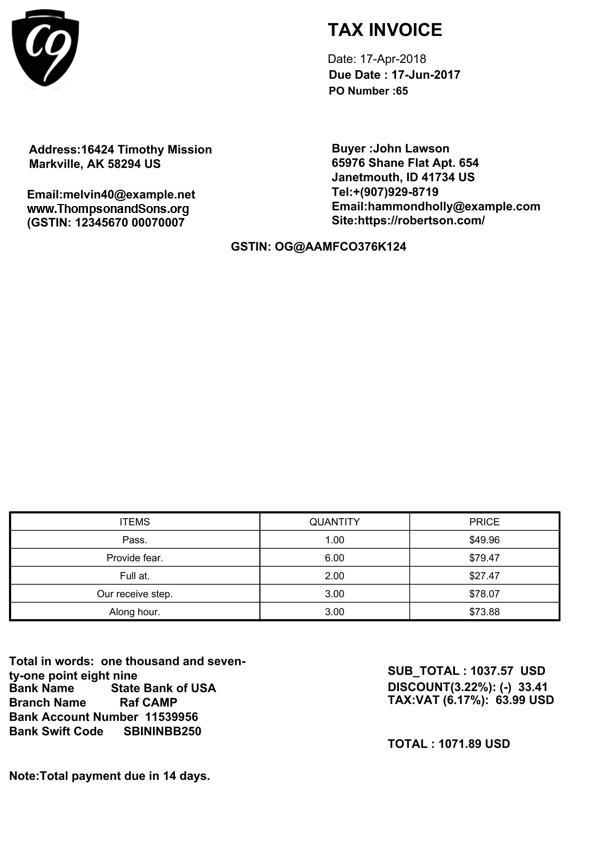

In [79]:
# for gt, pred in zip(curr_gt, curr_pred):
from TFG.utils.validation_utils import lowercase_keys


print(f"Current folder: {curr_folder}")
gt, pred  = curr_gt[j], curr_pred[j]
pred = lowercase_keys(pred)
curr_file  = data[j]
diff_keys = any_diff(gt, pred)
while len(diff_keys) == 0: # or 'address' not in diff_keys: #or 'total' not in diff_keys:
    j+=1
    gt, pred  = curr_gt[j], curr_pred[j]
    pred = lowercase_keys(pred)
    curr_file  = data[j]
    diff_keys = any_diff(gt, pred)
    
print(f"{'Field':>8} | {'Type':^5} | {'Value'}\n")
for k_gt, v_gt in gt.items():
    v_pred = pred.get(k_gt, '')
    red = k_gt in diff_keys
    #             red                   green
    color = "\033[31m" if red else "\033[32m"
    reset_text = "\033[0m"

    # Print the values with conditional red coloring
    print(f"{k_gt:>8} | {'Gt':>5} | {v_gt} ")
    print(f"{color}{'':>8} | {'Pred':>5} | {v_pred}{reset_text}")
    
file_name = curr_file['file_name']
print(f"\nCurrent file: {file_name}")
image = Image.open(os.path.join("final_dataset_fatura/test", file_name))
display.display(image)

j+=1